# LeetCode #34: Find First and Last Position of Element in Sorted Array

https://leetcode.com/problems/find-first-and-last-position-of-element-in-sorted-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Optimal: Two Binary Searches ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan left to right to find the first occurrence, then scan right to left for the last. Correct but $O(n)$ — ignores the sorted order entirely.

### Optimal: Two Binary Searches ★
Run one binary search biased leftward (continue narrowing right when a match is found) to locate the first occurrence, and a second biased rightward (continue narrowing left when a match is found) to locate the last. Each search is $O(\log n)$, giving $O(\log n)$ overall with $O(1)$ space.

**Constraints:**
* 0 <= nums.length <= 10^5
* -10^9 <= nums[i] <= 10^9
* nums is sorted in non-decreasing order
* -10^9 <= target <= 10^9


## Solutions

### C#

In [ ]:
public int[] SearchRange(int[] nums, int target) {
    return new int[] { FindFirst(nums, target), FindLast(nums, target) };
}

int FindFirst(int[] nums, int target) {
    int lo = 0, hi = nums.Length - 1, result = -1;
    while (lo <= hi) {
        int mid = lo + (hi - lo) / 2;
        if (nums[mid] == target) {
            result = mid;   // Record match, keep searching left for earlier occurrence
            hi = mid - 1;
        } else if (nums[mid] < target) lo = mid + 1;
        else hi = mid - 1;
    }
    return result;
}

int FindLast(int[] nums, int target) {
    int lo = 0, hi = nums.Length - 1, result = -1;
    while (lo <= hi) {
        int mid = lo + (hi - lo) / 2;
        if (nums[mid] == target) {
            result = mid;   // Record match, keep searching right for later occurrence
            lo = mid + 1;
        } else if (nums[mid] < target) lo = mid + 1;
        else hi = mid - 1;
    }
    return result;
}


### Python

In [ ]:
def searchRange(self, nums: list[int], target: int) -> list[int]:
    return [self._find_first(nums, target), self._find_last(nums, target)]

def _find_first(self, nums: list[int], target: int) -> int:
    lo, hi, result = 0, len(nums) - 1, -1
    while lo <= hi:
        mid = lo + (hi - lo) // 2
        if nums[mid] == target:
            result = mid    # Record match, keep searching left for earlier occurrence
            hi = mid - 1
        elif nums[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return result

def _find_last(self, nums: list[int], target: int) -> int:
    lo, hi, result = 0, len(nums) - 1, -1
    while lo <= hi:
        mid = lo + (hi - lo) // 2
        if nums[mid] == target:
            result = mid    # Record match, keep searching right for later occurrence
            lo = mid + 1
        elif nums[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return result


### Go

In [ ]:
func searchRange(nums []int, target int) []int {
    findFirst := func() int {
        lo, hi, result := 0, len(nums)-1, -1
        for lo <= hi {
            mid := lo + (hi-lo)/2
            if nums[mid] == target {
                result = mid  // Record match, keep searching left for earlier occurrence
                hi = mid - 1
            } else if nums[mid] < target {
                lo = mid + 1
            } else {
                hi = mid - 1
            }
        }
        return result
    }
    findLast := func() int {
        lo, hi, result := 0, len(nums)-1, -1
        for lo <= hi {
            mid := lo + (hi-lo)/2
            if nums[mid] == target {
                result = mid  // Record match, keep searching right for later occurrence
                lo = mid + 1
            } else if nums[mid] < target {
                lo = mid + 1
            } else {
                hi = mid - 1
            }
        }
        return result
    }
    return []int{findFirst(), findLast()}
}


### Rust

In [ ]:
pub fn search_range(nums: Vec<i32>, target: i32) -> Vec<i32> {
    let find_first = || {
        let (mut lo, mut hi, mut result) = (0i32, nums.len() as i32 - 1, -1i32);
        while lo <= hi {
            let mid = lo + (hi - lo) / 2;
            if nums[mid as usize] == target {
                result = mid;  // Record match, keep searching left for earlier occurrence
                hi = mid - 1;
            } else if nums[mid as usize] < target {
                lo = mid + 1;
            } else {
                hi = mid - 1;
            }
        }
        result
    };
    let find_last = || {
        let (mut lo, mut hi, mut result) = (0i32, nums.len() as i32 - 1, -1i32);
        while lo <= hi {
            let mid = lo + (hi - lo) / 2;
            if nums[mid as usize] == target {
                result = mid;  // Record match, keep searching right for later occurrence
                lo = mid + 1;
            } else if nums[mid as usize] < target {
                lo = mid + 1;
            } else {
                hi = mid - 1;
            }
        }
        result
    };
    vec![find_first(), find_last()]
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [5, 7, 7, 8, 8, 10], target = 8
FindFirst: mid=2(7)<8→lo=3; mid=4(8)→result=4,hi=3; mid=3(8)→result=3,hi=2; done→first=3. FindLast: mid=4(8)→result=4,lo=5; mid=5(10)>8→hi=4; done→last=4. Returns [3,4].

**2. Slightly Complex**
**Input:** nums = [1, 1, 1, 1, 1], target = 1
FindFirst keeps halving left until lo=0; FindLast keeps halving right until last=4. Both searches run $O(\log 5) \approx 3$ iterations yet still handle the entire range correctly.

**3. Edge Case: Time Factor**
**Input:** nums = [1, 2, 3, ..., 100000], target = 100000
FindFirst finds 100000 at index 99999 then exhausts the right sub-range (hi=99998). FindLast records 99999 and moves lo past it immediately. Total iterations $\approx 2 \times \lceil \log_2 10^5 \rceil \approx 34$ — worst case for largest array.

**4. Edge Case: Space Factor**
**Input:** nums = [], target = 0
Both FindFirst and FindLast enter with hi=-1, so the while loop never executes. Returns [-1,-1] in $O(1)$ time with only the three pointer variables allocated — confirms $O(1)$ space even on empty input.

**5. Almost-Impossible but Plausible**
**Input:** nums = [-10^9, -10^9, ..., -10^9] (10^5 copies), target = -10^9
Every element matches. FindFirst must narrow all the way left (result updates each iteration, hi shrinks to 0). FindLast narrows all the way right (lo grows to 99999). Both take $\lceil \log_2 10^5 \rceil = 17$ steps, returning [0, 99999] — the full range.


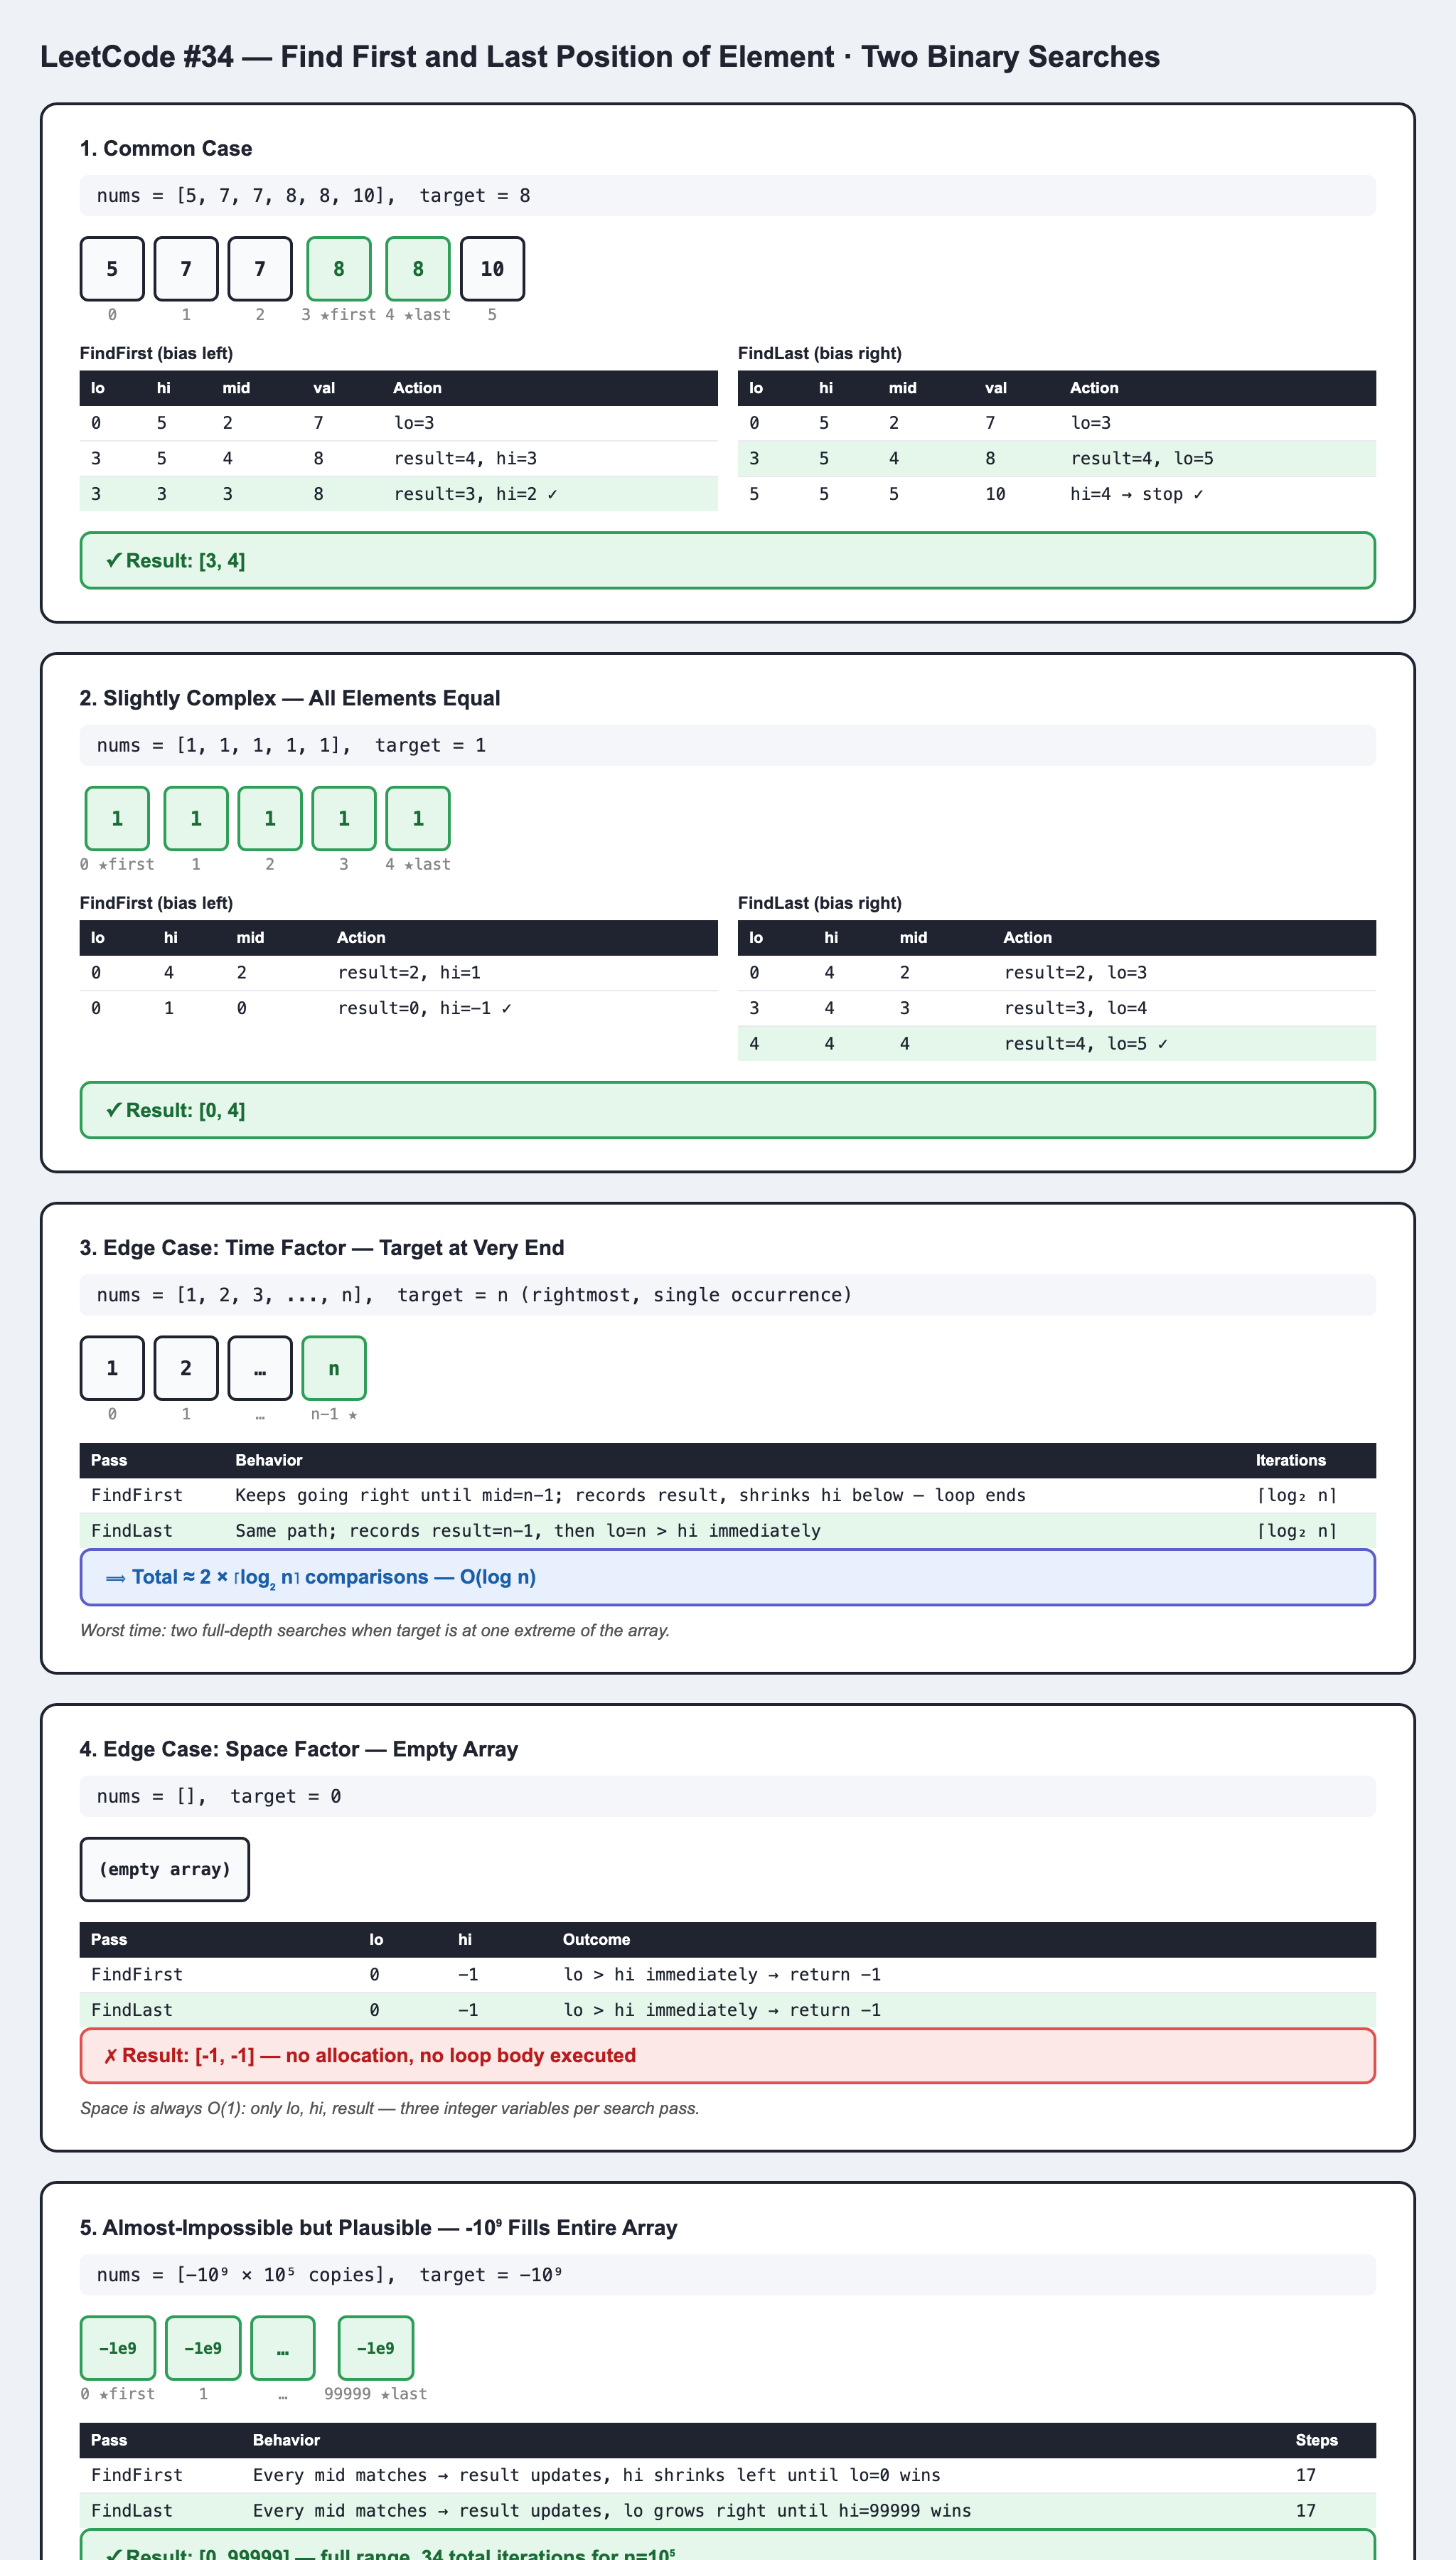